In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from matlabtools import Struct
from fullwave2d.config.definitions import DATA_FDOP_DIR


def plot_semi_log10(ax, xdata, ydata, **plot_kwargs):
    ax.plot(xdata, 10 * np.log10(ydata), **plot_kwargs)
    
from FW2D.processing.fit_utils import *
from FW2D.processing.sigprocessing import show_spec
from FW2D import DataInterface
import h5py

from scipy.optimize import curve_fit

def power_law_model(x, A, alpha):
    return A * x**alpha 
def power_law_model2(x, A, alpha):
    return A * x**alpha / (1 + x**2)


In [2]:
def compute_profile(out):
    from scipy import constants as cnst

    val = out.validated == 1
    out.kp = 4 * np.pi * out.freqGHz * 1e9 / cnst.c * np.sin(out.theta * np.pi / 180) / 100 # cm-1

    out.v_perp = (2 * np.pi * out.fDop) / (out.kp * 1e2)
    out.dv_perp = (2 * np.pi * out.dfDop) / (out.kp * 1e2)
    out.v_min= (2 * np.pi * out.fDop_min) / (out.kp * 1e2)
    out.v_max = (2 * np.pi * out.fDop_max) / (out.kp * 1e2)
    out.yerr = np.array([np.abs(out.v_min - out.v_perp),
                                np.abs(out.v_max - out.v_perp)])
    
    ET = np.zeros_like(out.fDop)
    EL  = np.copy(ET)
    EG  = np.copy(ET)
    NormS  = np.copy(ET)

    for i, s in enumerate(out.specobjs):
        xfit = np.linspace(s.f.min(), s.f.max(), 1000)
        Tfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
        Lfit = lorentzian(xfit / s.xscale, *s.fit_params.lorentzian,) * s.yscale + s.P_noise
        Gfit = gaussian(xfit / s.xscale, *s.fit_params.gaussian,) * s.yscale + s.P_noise
        ET[i] = np.trapz(Tfit, xfit )
        EL[i] = np.trapz(Lfit, xfit )
        EG[i] = np.trapz(Gfit, xfit )
        NormS[i] = s.NormS
        
        if ET[i] < 0.1 * s.rms:
            ET[i] = np.mean([EL[i], EG[i], NormS[i]])
        
    dET = np.std([ET, EG, EL, NormS], axis = 0)
    
    out.ET  = ET
    out.dET = dET
        
    return out

def AngularAveragePSD(F, kx, ky, n_bins = 200):

    kn = (kx**2 + ky**2)**0.5
    k_min, k_max = kn.min(), kn.max()
    k_bins_edges = np.linspace(k_min, k_max, n_bins + 1)
    k_bins = 0.5 * (k_bins_edges[:-1] + k_bins_edges[1:])

    S = np.zeros(n_bins)
    counts = np.zeros(n_bins)

    kn_flat = kn.ravel()
    F_flat = F.ravel()

    # Digitize radial wavenumbers into bins
    inds = np.digitize(kn_flat, k_bins_edges)

    for i in range(1, n_bins + 1):
        mask = (inds == i)
        if np.any(mask):
            S[i-1] = np.mean(F_flat[mask])
            counts[i-1] = np.sum(mask)
        else:
            S[i-1] = 0

    return k_bins, S #* k_bins

In [3]:
out_adv = Struct.from_mat(DATA_FDOP_DIR.joinpath('FWS_advection.mat'), 'outp')
prof_adv = compute_profile(out_adv)

### ITG - TEM 2

In [145]:
# Read spectrum parameter
output_file = '/home/FO278650/Bureau/FullWave2D_FO/data/maps/advection_ITG_TEM.h5'
with h5py.File(output_file, "r") as f:
    # n_txky = f['fields/n'][:]
    # omega  = f['profiles/omega_ky'][:]
    # ky         = f['grid/ky'][:]
    omega_ITG = f['profiles/omega_ITG'][:]
    omega_TEM = f['profiles/omega_TEM'][:]
    omega_ky = f['profiles/omega_ky'][:]
    kx        = f['grid/kx'][:]
    ky        = f['grid/ky'][:]
    fkI       = f['spectrum/fkI'][:]
    fkT       = f['spectrum/fkT'][:]
    U0        = f.attrs['U0'][0]
    rhos      = f.attrs['rhos']
    AI        = f.attrs['AI']
    AT        = f.attrs['AT']

f.close()
_kyl = ky / rhos
_kxl = kx / rhos




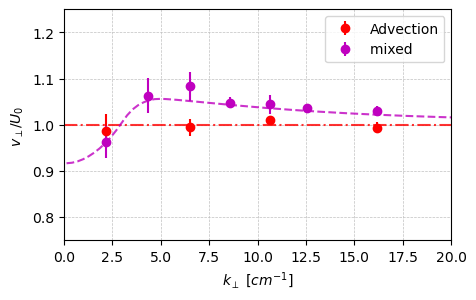

In [146]:
out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection_2.mat'), 'outp')
prof = compute_profile(out)

fig, ax = plt.subplots(figsize = (5,3))
ax.axhline(1, c = 'r', ls = '-.', alpha = 0.8)
ax.errorbar(prof_adv.kp[prof_adv.validated == 1], prof_adv.v_perp[prof_adv.validated == 1] / U0, yerr = prof_adv.yerr[:,prof_adv.validated == 1] / U0, fmt = 'or', label = 'Advection' )

val = prof.validated == 1
ax.plot(_kyl *1e-2 , (U0 + omega_ky / _kyl) / U0,  '--m', alpha = 0.8 )
ax.errorbar(prof.kp[val], prof.v_perp[val] / U0, yerr = prof.dv_perp[val] / U0, fmt = 'om', label = 'mixed ')


ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
plt.show()

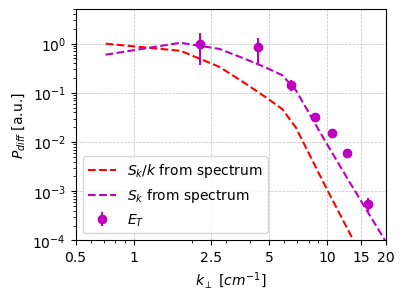

In [149]:
fig, ax = plt.subplots(figsize = (4,3))
_kx, _ky = np.meshgrid(_kxl, _kyl, indexing = 'ij')
ks, Sk = AngularAveragePSD(np.abs(AI * fkI + AT * fkT)**2, _kx, _ky)
ks *= 1e-2

ax.loglog(ks , (Sk / ks) / (Sk / ks).max(), ls = '--', c = 'r', label = r'$S_k / k$ from spectrum')
ax.loglog(ks , Sk, ls = '--', c = 'm', label = r'$S_k$ from spectrum')
ax.errorbar(out.kp[val], prof.ET[val] / prof.ET.max(), yerr = prof.dET[val] * 2/ prof.ET.max(), fmt = 'om', label = r'$E_{T}$')
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(0.5, 20)
ax.set_ylim(1e-4, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$P_{diff}$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([ 0.5, 1, 2.5, 5, 10, 15, 20])
ax.set_xticklabels([ "0.5", "1", "2.5", "5", "10", "15", "20"])
plt.show()

(0.0001, 5)

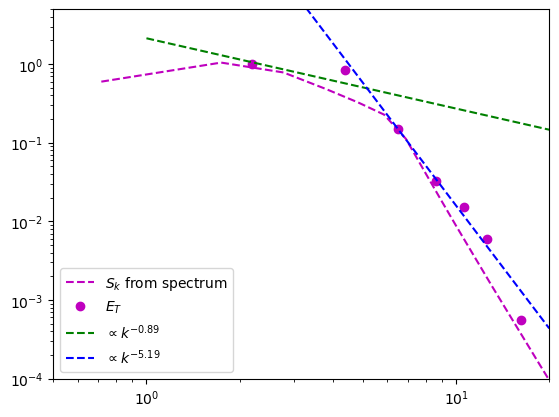

In [9]:
kfit = np.linspace(1, 20, 100)
plt.loglog(ks , Sk, ls = '--', c = 'm', label = r'$S_k$ from spectrum')

plt.loglog(out.kp[val], prof.ET[val] / prof.ET.max(), 'om', label = r'$E_{T}$')

cond = (out.kp < 7 ) & val
popt, pcov = curve_fit(power_law_model, out.kp[cond], prof.ET[cond], p0=[1,-1])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
plt.loglog(kfit, power_law_model(kfit, *popt) / prof.ET.max()  ,  c = 'g', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

cond = (out.kp >= 6 ) & val
popt, pcov = curve_fit(power_law_model, out.kp[cond], prof.ET[cond], p0=[1,-1])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
plt.loglog(kfit, power_law_model(kfit, *popt) / prof.ET.max()  ,  c = 'b', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

plt.legend()
plt.xlim(0.5, 20)
plt.ylim(1e-4, 5)


#### Waist study

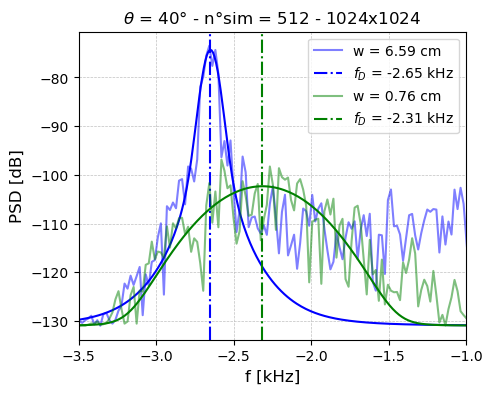

In [284]:
out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection_2.mat'), 'outp')
dI = DataInterface('mixed_advection_2')
fig, ax = plt.subplots(figsize = (5, 4))

i = 5
s = out.specobjs[i]
inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
noise = s.P_noise
plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'b', label = 'w = %.2f cm' %(inp.waist * 1e2), alpha = 0.5)
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'b')
ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'b', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))

# i = 7 
# s = out.specobjs[i]
# inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
# plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'r',  label = 'w = %.2f cm' %(inp.waist * 1e2), alpha = 0.5)
# xfit = np.linspace(s.f.min(), s.f.max(), 1000)
# plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'r')
# ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'r', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))

i = 8
s = out.specobjs[i]
inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'g',  label = 'w = %.2f cm' %(inp.waist * 1e2) , alpha = 0.5)
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'g')
ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'g', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))


# ax.set_xlim(-4,4)

ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.legend()

ax.set_ylabel('PSD [dB]', fontsize = 12)
ax.set_xlabel('f [kHz]', fontsize = 12)
ax.set_title(r'$\theta$ = 40° - n°sim = 512 - 1024x1024')
ax.set_xlim(-3.5, -1)
plt.show()

#### nfft study

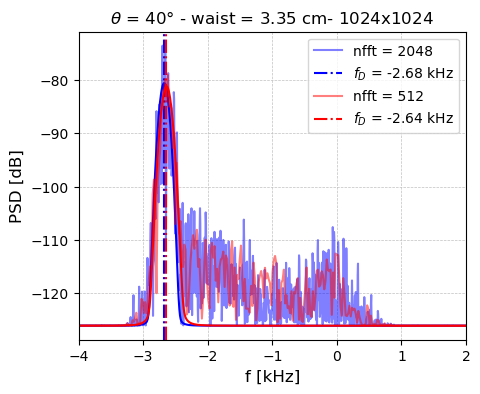

In [287]:
fig, ax = plt.subplots(figsize = (5, 4))


# i = 9
# s = out.specobjs[i]
# inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
# plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'g', label = 'nfft = 1024', alpha = 0.5)
# xfit = np.linspace(s.f.min(), s.f.max(), 1000)
# plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'g')
# ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'g', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))


i = 10
s = out.specobjs[i]
inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'b', label = 'nfft = 2048', alpha = 0.5)
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'b')
ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'b', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))

i = 7
s = out.specobjs[i]

inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
noise = s.P_noise
plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'r', label = 'nfft = 512', alpha = 0.5)
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'r')
ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'r', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))


ax.set_xlim(-4, 2)
ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.legend()

ax.set_ylabel('PSD [dB]', fontsize = 12)
ax.set_xlabel('f [kHz]', fontsize = 12)
ax.set_title(r'$\theta$ = 40° - waist = %.2f cm- 1024x1024' %(inp.waist * 1e2))

plt.show()

#### size of map study 


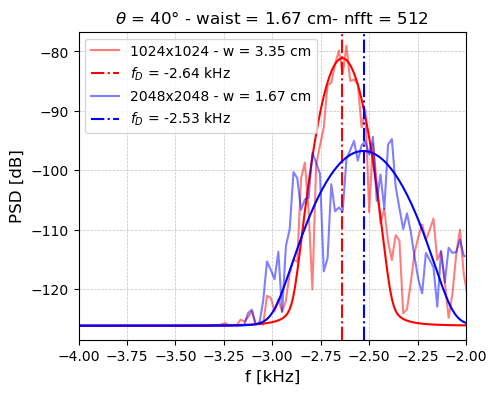

In [290]:
fig, ax = plt.subplots(figsize = (5, 4))

out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection_2.mat'), 'outp')
dI = DataInterface('mixed_advection_2')
i = 7
inp = InputData.load_pickle(dI.params.name[i], subdir = dI.subdir, machine = 'irene')
s = out.specobjs[i]
noise = s.P_noise
plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'r', label = '1024x1024 - w = %.2f cm' %(inp.waist * 1e2), alpha = 0.5)
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'r')
ax.axvline(out.fDop[i] * 1e-3, ls = '-.', c = 'r', label = r'$f_{D}$ = %.2f kHz' %(out.fDop[i] * 1e-3))


out1 = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection_2_large.mat'), 'outp')
s = out1.specobjs
dI = DataInterface('mixed_advection_2_large')
inp = InputData.load_pickle(dI.params.name[0], subdir = dI.subdir, machine = 'irene')

plot_semi_log10(ax, s.f / s.xscale, s.P + noise, c = 'b', label = '2048x2048 - w = %.2f cm' %(inp.waist * 1e2),alpha = 0.5)
xfit = np.linspace(s.f.min(), s.f.max(), 1000)
plot_semi_log10(ax, xfit / s.xscale, taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + noise, c = 'b')
ax.axvline(out1.fDop * 1e-3, ls = '-.', c = 'b', label = r'$f_{D}$ = %.2f kHz' %(out1.fDop * 1e-3))

ax.set_xlim(-4, -2)
ax.grid(c = 'silver', ls = '--', lw = 0.5)
ax.legend()

ax.set_ylabel('PSD [dB]', fontsize = 12)
ax.set_xlabel('f [kHz]', fontsize = 12)
ax.set_title(r'$\theta$ = 40° - waist = %.2f cm- nfft = 512' %(inp.waist * 1e2))

plt.show()

### mixed 1


In [10]:
Nx, Ny = 1024, 1024 # padded resolution
#Nx, Ny = 2 * int(np.floor(Npx/3)), 2 * int(np.floor(Npy/3)) # Fourier space resolution
# Lx, Ly = 32*np.pi, 32*np.pi #Size of the box, which sets the Fourier space resolution dkx, dky = 2*pi/Lx, 2*pi/Ly
dx,dy=2e-4, 2e-4
dt, Nt = 1e-4, 600
Lx, Ly = dx * Nx, dy * Ny
dkx,dky=2*np.pi/Lx, 2*np.pi/Ly
xl,yl=np.arange(0,Lx,dx),np.arange(0,Ly,dy)
x,y=np.meshgrid(xl,yl,indexing="ij")
kxl=np.r_[0.1:int(Nx/2),-int(Nx/2):-0.1]*dkx
kyl=np.r_[0.1:int(Ny/2+1)]*dky
kx,ky=np.meshgrid(kxl,kyl,indexing='ij')

# physics setting 
U0         = -10 * np.ones(Nx) # 4.0 
S          = 0 # -30  #-50
dt, Nt     = 1e-4, 600
phase      = np.exp(1j * 2 * np.pi * np.random.random(kx.shape) - np.pi)


a, b = 1, 2
thtI = -np.pi / 3
kperpI = np.sqrt((kx * np.cos(thtI) + ky * np.sin(thtI)) ** 2 / a ** 2+ (kx * np.sin(thtI) - ky * np.cos(thtI)) ** 2 / b ** 2)

kperp = np.sqrt(kx  ** 2 + ky ** 2 )
# kperp = kperpI

k0I=0.2*1e3
sigI=0.08*1e3
alpI= 3# 3.0
betI=1.0

AI= 1.0

k0T=1*1e3
sigT=0.2*1e3
alpT= 6# 6
betT=1.8
AT= 1


k2I = k0I / 2 * (1 + np.sqrt(1 + 4 * alpI * sigI**2 / k0I ** 2))
k1I = k0I / 2 * (1 + np.sqrt(1 - 4 * betI * sigI**2 / k0I ** 2))
BI = AI * np.exp(- (k2I - k0I) ** 2 / (2 * sigI ** 2)) * k2I ** alpI
CI = AI * np.exp(- (k1I - k0I) ** 2 / (2 * sigI ** 2)) * k1I ** (-betI)
fkI = AI * np.exp(- (kperpI - k0I) **2 / (2 * sigI **2)) * (kperpI < k2I) * (kperpI >= k1I) + BI * kperpI **(-alpI) * (kperpI >= k2I) + CI * kperpI ** betI * (kperpI < k1I)
nkI = fkI *  phase
nkI[-1:-int(Nx/2):-1,0]=nkI[1:int(Nx/2),0].conj()

k2T = k0T / 2 * (1 + np.sqrt(1 + 4 * alpT * sigT**2 / k0T ** 2))
k1T = k0T / 2 * (1 + np.sqrt(1 - 4 * betT * sigT**2 / k0T ** 2))
BT = AT * np.exp(- (k2T - k0T) ** 2 / (2 * sigT ** 2)) * k2T ** alpT
CT = AT * np.exp(- (k1T - k0T) ** 2 / (2 * sigT ** 2)) * k1T ** (-betT)
fkT = AT * np.exp(- (kperp - k0T) **2 / (2 * sigT **2)) * (kperp < k2T) * (kperp >= k1T) + BT * kperp **(-alpT) * (kperp >= k2T) + CT * kperp ** betT * (kperp < k1T)
nkT = fkT  * phase
nkT[-1:-int(Nx/2):-1,0]=nkT[1:int(Nx/2),0].conj()

fk = fkI + fkT
fk2 = 1 * fkI + 0.6 * fkT
fk3 = 1 * fkI + 0.4 * fkT
fk4 = 1 * fkI + 0.1 * fkT

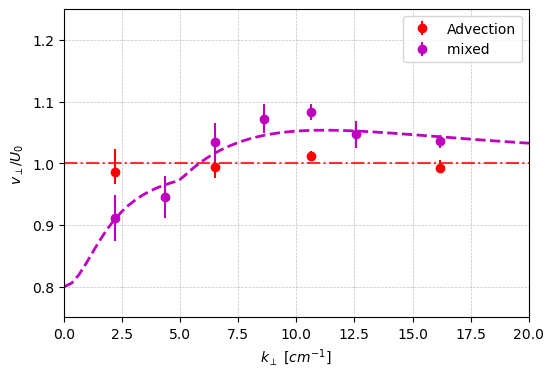

In [15]:
Nx, Ny = 1024, 1024
dx,dy=2e-4, 2e-4
Ly = dy * Ny
dky= 2*np.pi/Ly
kyl=np.r_[0.1:int(Ny/2+1)]*dky
k0I=0.2*1e3
k0T=1*1e3

Ti = 2
Te = 1.5
omega_ITG =  Ti * kyl / (1 + (kyl/(k0I ))**2)
omega_TEM = -Te* (kyl - k0T*0.5 ) / (1 + ((kyl - k0T*0.5 )/(k0T ))**2) * (kyl > 0.5 * k0T ) + np.zeros_like(kyl) * (kyl > 0.25 * k0T )
omega_eff_ky = 1.0 * omega_ITG + 1.0 * omega_TEM

U0 = -10
FWS_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_advection.mat')
FWS_mixed_advection = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_mixed_advection.mat')

fig, ax = plt.subplots(figsize = (6, 4))
ax.axhline(1, c = 'r', ls = '-.', alpha = 0.8)
ax.errorbar(prof_adv.kp[prof_adv.validated == 1], prof_adv.v_perp[prof_adv.validated == 1] / U0, yerr = prof_adv.yerr[:,prof_adv.validated == 1] / U0, fmt = 'or', label = 'Advection' )

ax.plot(kyl *1e-2 , (U0 + omega_eff_ky / kyl) / U0,  '--', lw =2, c = 'm', )


out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection.mat'), 'outp')
ax.errorbar(prof.kp[val], prof.v_perp[val] / U0, yerr = prof.dv_perp[val] / U0, fmt = 'om', label = 'mixed ')
ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)




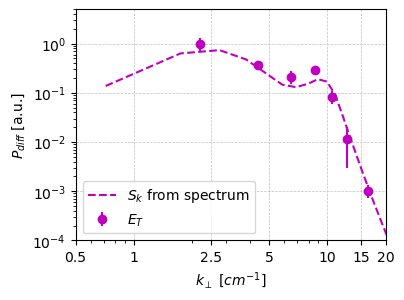

In [17]:

fig, ax = plt.subplots(figsize = (4,3))
ks, Sk = AngularAveragePSD(np.abs(fk3)**2, _kx, _ky)
ks *= 1e-2
ax.loglog(ks , Sk, ls = '--', c = 'm', label = r'$S_k$ from spectrum')
ax.errorbar(prof.kp[val], prof.ET[val] / prof.ET.max(), yerr = prof.dET[val] * 2/ prof.ET.max(), fmt = 'om', label = r'$E_{T}$')
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(0.5, 20)
ax.set_ylim(1e-4, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$P_{diff}$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([ 0.5, 1, 2.5, 5, 10, 15, 20])
ax.set_xticklabels([ "0.5", "1", "2.5", "5", "10", "15", "20"])
plt.show()


(0.0001, 5)

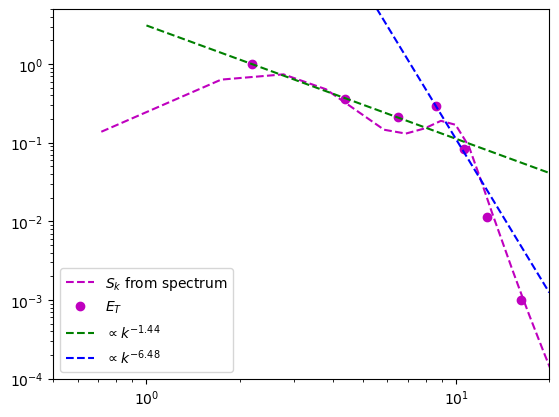

In [337]:
kfit = np.linspace(1, 20, 100)
plt.loglog(ks , Sk, ls = '--', c = 'm', label = r'$S_k$ from spectrum')

plt.loglog(out.kp[val], prof.ET[val] / prof.ET.max(), 'om', label = r'$E_{T}$')

cond = (out.kp < 7 ) & val
popt, pcov = curve_fit(power_law_model, out.kp[cond], prof.ET[cond], p0=[1,-1])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
plt.loglog(kfit, power_law_model(kfit, *popt) / prof.ET.max()  ,  c = 'g', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

cond = (out.kp >= 8 ) & val
popt, pcov = curve_fit(power_law_model, out.kp[cond], prof.ET[cond], p0=[1,-5])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
plt.loglog(kfit, power_law_model(kfit, *popt) / prof.ET.max()  ,  c = 'b', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

plt.legend()
plt.xlim(0.5, 20)
plt.ylim(1e-4, 5)

In [47]:
P_diff = np.zeros_like(out.fDop)
NormS  = np.copy(P_diff)

for i, s in enumerate(out.specobjs):
    xfit = np.linspace(s.f.min(), s.f.max(), 1000)
    yfit = taylor(xfit / s.xscale, *s.fit_params.taylor, dt=s.dt * s.xscale) * s.yscale + s.P_noise
    Pd = np.trapz(yfit, xfit )
    if  Pd < 0.1 * s.rms:
        P_diff[i] = np.nan
    else:
        P_diff[i] = Pd
    NormS[i] = s.NormS
    
import h5py




file /home/FO278650/Bureau/FullWave2D_FO/data/maps/advection_ITG_TEM.h5 read


In [21]:
Nx, Ny = 1024, 1024 # padded resolution
#Nx, Ny = 2 * int(np.floor(Npx/3)), 2 * int(np.floor(Npy/3)) # Fourier space resolution
# Lx, Ly = 32*np.pi, 32*np.pi #Size of the box, which sets the Fourier space resolution dkx, dky = 2*pi/Lx, 2*pi/Ly
dx,dy=2e-4, 2e-4
dt, Nt = 1e-4, 600
Lx, Ly = dx * Nx, dy * Ny
dkx,dky=2*np.pi/Lx, 2*np.pi/Ly
xl,yl=np.arange(0,Lx,dx),np.arange(0,Ly,dy)
x,y=np.meshgrid(xl,yl,indexing="ij")
kxl=np.r_[0.1:int(Nx/2),-int(Nx/2):-0.1]*dkx
kyl=np.r_[0.1:int(Ny/2+1)]*dky
kx,ky=np.meshgrid(kxl,kyl,indexing='ij')

# physics setting 
U0         = -10 * np.ones(Nx) # 4.0 
S          = 0 # -30  #-50
dt, Nt     = 1e-4, 600
phase      = np.exp(1j * 2 * np.pi * np.random.random(kx.shape) - np.pi)


a, b = 1, 2
thtI = -np.pi / 3
kperpI = np.sqrt((kx * np.cos(thtI) + ky * np.sin(thtI)) ** 2 / a ** 2+ (kx * np.sin(thtI) - ky * np.cos(thtI)) ** 2 / b ** 2)

kperp = np.sqrt(kx  ** 2 + ky ** 2 )
# kperp = kperpI

k0I=0.2*1e3
sigI=0.08*1e3
alpI= 3# 3.0
betI=1.0

AI= 1.0

k0T=1*1e3
sigT=0.2*1e3
alpT= 6# 6
betT=1.8
AT= 1


k2I = k0I / 2 * (1 + np.sqrt(1 + 4 * alpI * sigI**2 / k0I ** 2))
k1I = k0I / 2 * (1 + np.sqrt(1 - 4 * betI * sigI**2 / k0I ** 2))
BI = AI * np.exp(- (k2I - k0I) ** 2 / (2 * sigI ** 2)) * k2I ** alpI
CI = AI * np.exp(- (k1I - k0I) ** 2 / (2 * sigI ** 2)) * k1I ** (-betI)
fkI = AI * np.exp(- (kperpI - k0I) **2 / (2 * sigI **2)) * (kperpI < k2I) * (kperpI >= k1I) + BI * kperpI **(-alpI) * (kperpI >= k2I) + CI * kperpI ** betI * (kperpI < k1I)
nkI = fkI *  phase
nkI[-1:-int(Nx/2):-1,0]=nkI[1:int(Nx/2),0].conj()

k2T = k0T / 2 * (1 + np.sqrt(1 + 4 * alpT * sigT**2 / k0T ** 2))
k1T = k0T / 2 * (1 + np.sqrt(1 - 4 * betT * sigT**2 / k0T ** 2))
BT = AT * np.exp(- (k2T - k0T) ** 2 / (2 * sigT ** 2)) * k2T ** alpT
CT = AT * np.exp(- (k1T - k0T) ** 2 / (2 * sigT ** 2)) * k1T ** (-betT)
fkT = AT * np.exp(- (kperp - k0T) **2 / (2 * sigT **2)) * (kperp < k2T) * (kperp >= k1T) + BT * kperp **(-alpT) * (kperp >= k2T) + CT * kperp ** betT * (kperp < k1T)
nkT = fkT  * phase
nkT[-1:-int(Nx/2):-1,0]=nkT[1:int(Nx/2),0].conj()

fk = fkI + fkT
fk2 = 1 * fkI + 0.6 * fkT
fk3 = 1 * fkI + 0.4 * fkT
fk4 = 1 * fkI + 0.1 * fkT

In [ ]:


ks, Sk = AngularAveragePSD(np.abs(fk3)**2, kx, ky)
ks *= 1e-2

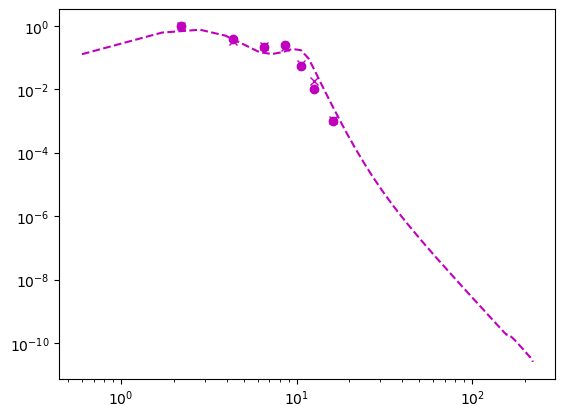

In [29]:

plt.loglog(ks , Sk, '--m', label = r'$A_{TEM} / A_{ITG}$ = %.1f' %AT)

plt.loglog(out.kp[out.validated == 1], P_diff[out.validated == 1] / np.nanmax(P_diff[out.validated == 1]) , 'om')
plt.loglog(out.kp[out.validated == 1], NormS[out.validated == 1] / np.nanmax(NormS[out.validated == 1]) , 'xm')

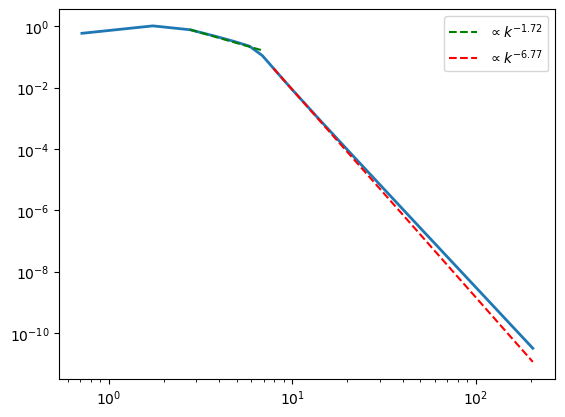

In [20]:
from scipy.optimize import curve_fit

def power_law_model(x, A, alpha):
    return A * x**alpha 
def power_law_model2(x, A, alpha):
    return A * x**alpha / (1 + x**2)

plt.loglog(ks, Sk, '-', lw = 2)

cond = (ks < 7 ) & (ks > 2)
popt, pcov = curve_fit(power_law_model, ks[cond], Sk[cond], p0=[1,-1])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
plt.loglog(ks[cond], power_law_model(ks[cond], *popt),  c = 'g', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

cond = ks > 7 
popt, pcov = curve_fit(power_law_model, ks[cond], Sk[cond], p0=[1,-3])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
plt.loglog(ks[cond], power_law_model(ks[cond], *popt),  c = 'r', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

plt.legend()

In [30]:
list(P_diff)

[0.004723728597165174,
 0.0007311453417572416,
 0.00018043442438961694,
 nan,
 3.306174644028277e-05,
 3.1093092225741602e-06,
 0.005703842518647291,
 1.0567101183399214e-06,
 3.364664731933972e-08,
 nan,
 9.662382374276924e-07]

ValueError: array must not contain infs or NaNs

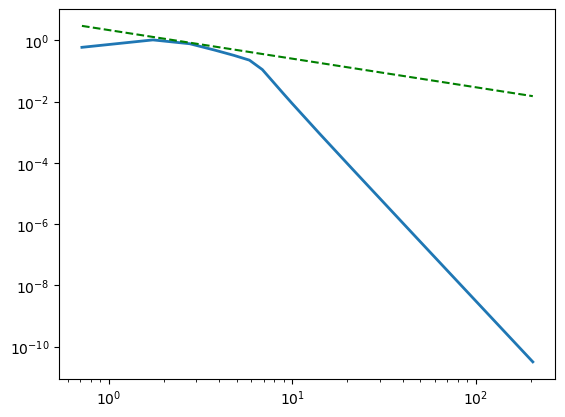

In [29]:
plt.loglog(ks, Sk, '-', lw = 2)

cond = (out.kp < 8 ) & (out.kp > 2)
popt, pcov = curve_fit(power_law_model, out.kp[ (out.validated == 1) & (cond)], P_diff[ (out.validated == 1) & (cond)] / np.nanmax(P_diff[out.validated == 1]), p0=[1,-1])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
kfit = np.linspace(ks.min(), ks.max())
plt.loglog(kfit, power_law_model(kfit, *popt),  c = 'g', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

cond = (out.kp > 8 ) & ()
popt, pcov = curve_fit(power_law_model, out.kp[ (out.validated == 1) & (cond)], P_diff[ (out.validated == 1) & (cond)] / np.nanmax(P_diff[out.validated == 1]), p0=[1,-1])  # initial guesses for A and alpha
A_fit, alpha_fit = popt
kfit = np.linspace(ks.min(), ks.max())
plt.loglog(kfit, power_law_model(kfit, *popt),  c = 'g', ls = '--',label = r'$\propto k^{%.2f}$'%alpha_fit)

plt.legend()

No handles with labels found to put in legend.


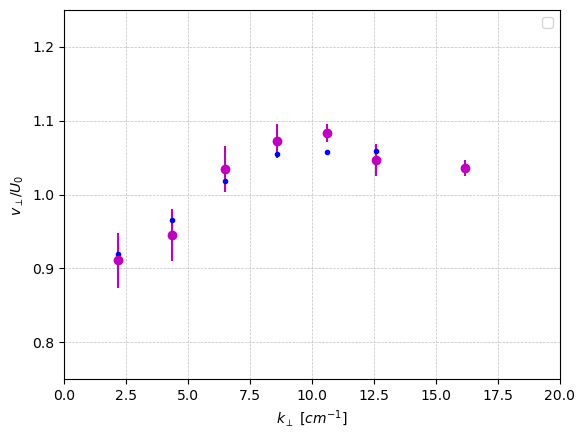

In [109]:
out_old = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_mixed_advection.mat')
out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection.mat'), 'outp')
prof = compute_profile(out)
val = prof.validated == 1

fig, ax = plt.subplots()

ax.plot(out_old.kp , out_old.v_perp /U0, 'b.' )
ax.errorbar(prof.kp[val], prof.v_perp[val] /U0,  yerr = prof.dv_perp[val] / U0, fmt = 'om' )
ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)


No handles with labels found to put in legend.


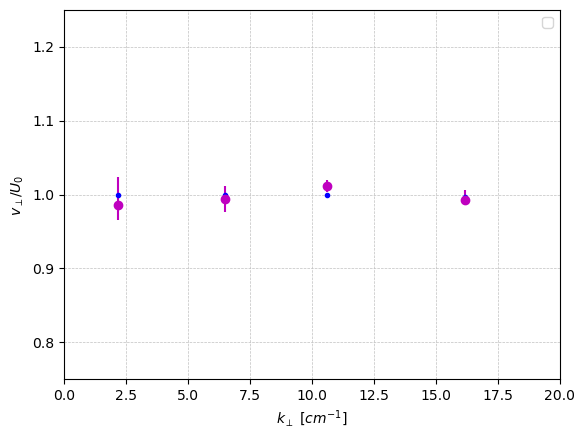

In [126]:
out_old = Struct.from_mat('/home/FO278650/Bureau/FullWave2D_FO/data/_results/FWS_advection.mat')
out = Struct.from_mat(DATA_FDOP_DIR.joinpath('FWS_advection.mat'), 'outp')
prof = compute_profile(out)
val = prof.validated == 1

fig, ax = plt.subplots()

ax.plot(out_old.kp , out_old.v_perp /U0, 'b.' )
ax.errorbar(prof.kp[val], prof.v_perp[val] /U0,  yerr = prof.yerr[:, val] / U0, fmt = 'om' )
ax.set_xlim(0, 20)
ax.set_ylim(0.75, 1.25)
ax.legend()
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
# 

In [123]:
out_old

__header__ : b'MATLAB 5.0 MAT-file Platform: posix, Created on: Wed Dec 17 19:28:21 2025'
__version__: 1.0
__globals__: []
theta      : [ 5 15 25 40]
fDop       : [ -348.8 -1035.9 -1691.  -2563. ]
k_perp     : [2.75093 4.82698 6.76533 9.27528]
kp         : [ 2.19198  6.50934 10.62891 16.1662 ]
v_perp     : [-9.99816 -9.9991  -9.9962  -9.9614 ]

### mixed 3

In [4]:
# Read spectrum parameter
output_file = '/home/FO278650/Bureau/FullWave2D_FO/data/maps/mixed/mixed_advection_3.h5'
with h5py.File(output_file, "r") as f:
    # n_txky = f['fields/n'][:]
    # omega  = f['profiles/omega_ky'][:]
    # ky         = f['grid/ky'][:]
    omega_ITG = f['profiles/omega_ITG'][:]
    omega_TEM = f['profiles/omega_TEM'][:]
    omega_ky = f['profiles/omega_ky'][:]
    kx        = f['grid/kx'][:]
    ky        = f['grid/ky'][:]
    x        = f['grid/x'][:]
    y        = f['grid/y'][:]
    fkI       = f['spectrum/fkI'][:]
    fkT       = f['spectrum/fkT'][:]
    U0        = f.attrs['U0'][0]
    dx        = f.attrs['dx']
    AI        = f.attrs['AI']
    AT        = f.attrs['AT']

f.close()
rhos = 2.2e-3
_kyl = ky / rhos
_kxl = kx / rhos



In [5]:
from scipy import constants as cnst
lambda0  = cnst.c / 60e9 
print(f'lambda0 / dx = {lambda0 / dx} (recommended > 20)')

lambda0 / dx = 23.13379471145184 (recommended > 20)


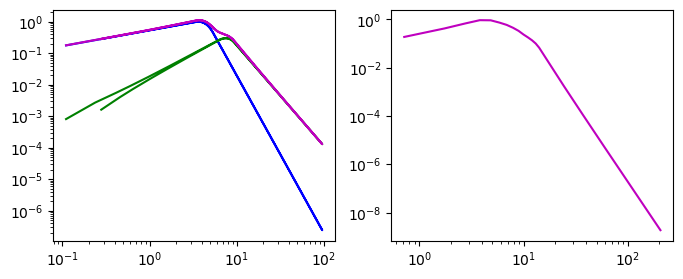

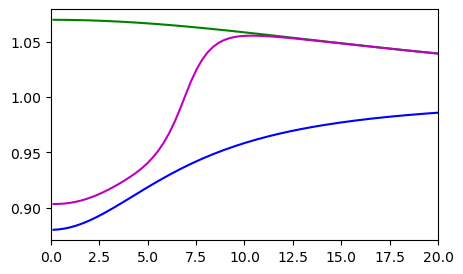

In [6]:
_kx, _ky = np.meshgrid(_kxl, _kyl, indexing = 'ij')
a, b = 1, 2
thtI = -np.pi / 3
kperpI = np.sqrt((_kx * np.cos(thtI) + _ky * np.sin(thtI)) ** 2 / a ** 2+ (_kx * np.sin(thtI) - _ky * np.cos(thtI)) ** 2 / b ** 2)

fig, ax = plt.subplots(1, 2, figsize = (8, 3))

ax[0].loglog(kperpI[:,0] * 1e-2, AI * fkI[:,0], c = 'b', label = 'ITG')
ax[0].loglog(kperpI[:,0] * 1e-2, AT * fkT[:,0], c = 'g', label = 'TEM')
ax[0].loglog(kperpI[:,0] * 1e-2, AI * fkI[:,0] + AT * fkT[:,0], c = 'm', label = 'mixed')

ks, Sk = AngularAveragePSD(np.abs(AI * fkI + AT * fkT)**2, _kx, _ky)
ax[1].loglog(ks * 1e-2, Sk, c = 'm')
plt.show()

fig, ax = plt.subplots(figsize = (5, 3))

ax.plot(_kyl * 1e-2, (U0 + omega_ITG / _kyl) / U0,  c = 'b', label = 'ITG')
ax.plot(_kyl * 1e-2, (U0 + omega_TEM / _kyl) / U0,  c = 'g', label = 'TEM')
ax.plot(_kyl * 1e-2, (U0 + omega_ky / _kyl) / U0,  c = 'm', label = 'mixed')
ax.set_xlim(0, 20)
plt.show()

In [26]:
out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection_3_waist300.mat'), 'outp')
prof300 = compute_profile(out)

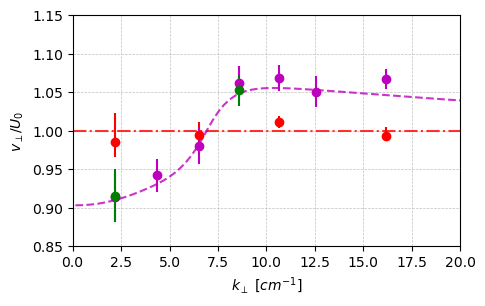

In [27]:
out = Struct.from_mat(DATA_FDOP_DIR.joinpath('FWS_advection.mat'), 'outp')
prof_adv = compute_profile(out)

out = Struct.from_mat(DATA_FDOP_DIR.joinpath('mixed_advection_3.mat'), 'outp')
prof = compute_profile(out)

fig, ax = plt.subplots(figsize = (5,3))
ax.axhline(1, c = 'r', ls = '-.', alpha = 0.8)
ax.errorbar(prof_adv.kp[prof_adv.validated == 1], prof_adv.v_perp[prof_adv.validated == 1] / U0, yerr = prof_adv.yerr[:,prof_adv.validated == 1] / U0, fmt = 'or', label = 'Advection' )

val = prof.validated == 1
ax.plot(_kyl *1e-2 , (U0 + omega_ky / _kyl) / U0,  '--m', alpha = 0.8 )
ax.errorbar(prof.kp[val], prof.v_perp[val] / U0, yerr = prof.dv_perp[val] / U0, fmt = 'om', label = 'mixed ')
val = prof300.validated == 1
ax.errorbar(prof300.kp[val], prof300.v_perp[val] / U0, yerr = prof300.dv_perp[val] / U0, fmt = 'og', label = 'mixed ')


ax.set_xlim(0, 20)
ax.set_ylim(0.85, 1.15)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$v_\perp / U_0$ ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
plt.show()

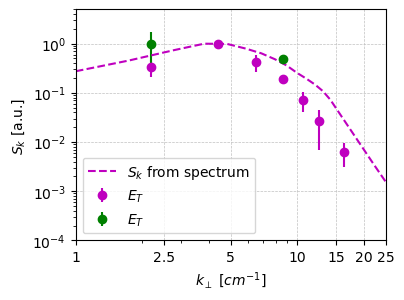

In [28]:
fig, ax = plt.subplots(figsize = (4,3))
_kx, _ky = np.meshgrid(_kxl, _kyl, indexing = 'ij')
ks, Sk = AngularAveragePSD(np.abs(AI * fkI + AT * fkT)**2, _kx, _ky)
ks *= 1e-2
# ax.loglog(ks , (Sk / ks) / (Sk / ks).max(), ls = '--', c = 'r', label = r'$S_k / k$ from spectrum')
ax.loglog(ks , Sk  / Sk .max(), ls = '--', c = 'm', label = r'$S_k $ from spectrum')

val = prof.validated == 1
ax.errorbar(prof.kp[val], prof.ET[val] / prof.ET.max(), yerr = prof.dET[val] * 2/ prof.ET.max(), fmt = 'om', label = r'$E_{T}$')
val = prof300.validated == 1
ax.errorbar(prof300.kp[val], prof300.ET[val] / prof300.ET.max(), yerr = prof300.dET[val] * 2/ prof300.ET.max(), fmt = 'og', label = r'$E_{T}$')
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlim(1, 25)
ax.set_ylim(1e-4, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$S_{k}$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
ax.set_xticks([1, 2.5, 5, 10, 15, 20, 25])
ax.set_xticklabels(["1", "2.5", "5", "10", "15", "20", "25"])
plt.show()

/tmp/ipykernel_3363289/3633316632.py:12: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax.pcolormesh(x * 1e2, y * 1e2, delta_ne, cmap = 'seismic')


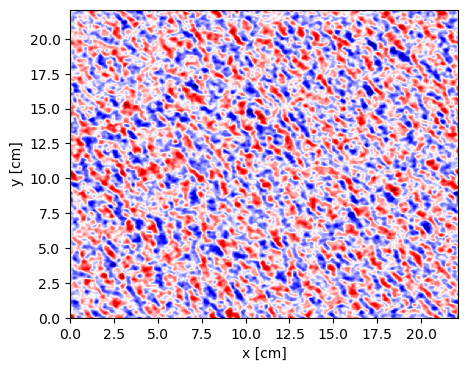

In [119]:
from fullwave2d.core.wrapper import InputData

inp = InputData.load_pickle('mixed_advection_3_f60_angle5_waist150', subdir = 'mixed_advection_3', machine = 'irene')

ne_lin = np.zeros((inp.ny, inp.nx))
for i in range(0, inp.ny):
    ne_lin[:,i] = -25 * (x - x.max()) * 2.2e19 + 3e17
    
delta_ne = 1 / 0.02 * (inp.ne / ne_lin.T -1)

fig, ax = plt.subplots(figsize = (5, 4))
ax.pcolormesh(x * 1e2, y * 1e2, delta_ne, cmap = 'seismic')
ax.set_xlabel('x [cm]')
ax.set_ylabel('y [cm]')
plt.show()

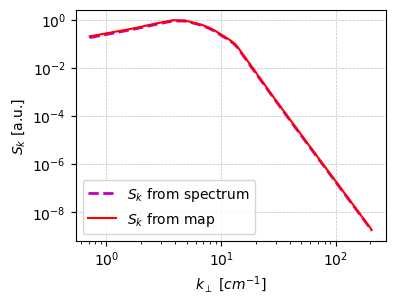

In [137]:
fig, ax = plt.subplots(figsize = (4,3))
dnk = np.fft.rfft2(delta_ne, norm='forward')
_ks, _Sk = AngularAveragePSD(np.abs(dnk) ** 2, _kx, _ky )
_ks *= 1e-2

ax.loglog(ks , Sk, ls = '--', c = 'm' , lw = 2,label = r'$S_k$ from spectrum')
ax.loglog(_ks , _Sk / _Sk.max(), c = 'r' , label = r'$S_k$ from map')

# ax.set_xlim(1, 25)
# ax.set_ylim(1e-4, 5)
ax.legend(loc = 3)
ax.set_xlabel(r'$k_\perp$ [$cm^{-1}$]', fontsize = 10)
ax.set_ylabel(r'$S_{k}$ [a.u.] ', fontsize = 10)
ax.grid(c = 'silver', ls= '--', lw = 0.5)
# ax.set_xticks([1, 2.5, 5, 10, 15, 20, 25])
# ax.set_xticklabels(["1", "2.5", "5", "10", "15", "20", "25"])
plt.show()